
Sample output:
   subject     sex  age                                         transcript  \
0        1    male   74  Well there's a mother standing there washing t...   
1        2  female   62  Somebody's getting cookies out of the cookie j...   
2        3  female   69  Okay. There's a little boy and he's standing o...   
3        4  female   71  Are you ready? Well the sink is overflowing. M...   
4        5  female   74  Okay. The mother's washing the dishes and the ...   

   ad  noun_ratio  verb_ratio  pronoun_ratio  adjective_ratio  adverb_ratio  \
0   0    0.376763   -0.852915      -0.869675         0.083981      0.259912   
1   0    1.139483   -0.312029      -2.017796        -0.470537      0.188141   
2   0    0.149384   -1.056298       0.151565         1.395957     -0.201761   
3   0   -0.781617    0.248360       0.511934         0.900467      0.086326   
4   0   -0.102183   -0.438318       0.150707         0.092338      0.268324   

   ...  pronoun_noun_ratio  function_wor

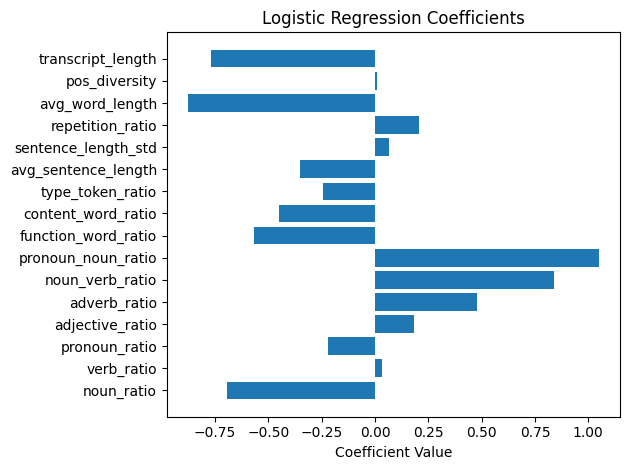

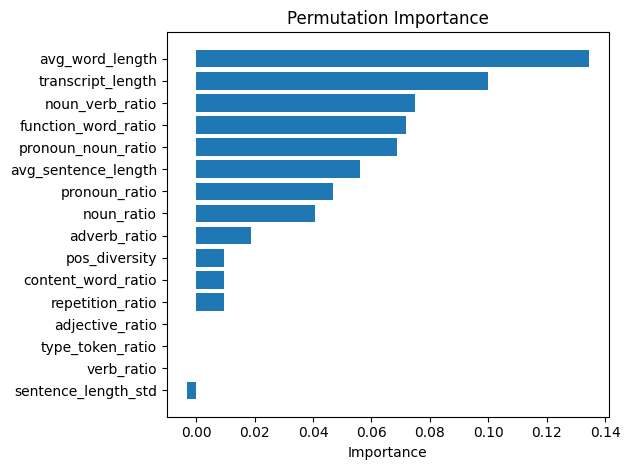

In [2]:
import pandas as pd
import numpy as np
import spacy
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score


# Load spaCy model
nlp = spacy.load("en_core_web_sm")


# Feature extraction (same as yours)
def extract_features(text):
    doc = nlp(str(text))
    
    tokens = [t for t in doc if not t.is_punct and not t.is_space]
    total_words = len(tokens)
    
    if total_words == 0:
        return {k: 0 for k in FEATURE_NAMES}
    
    pos_counts = Counter(t.pos_ for t in tokens)
    
    nouns = pos_counts["NOUN"]
    verbs = pos_counts["VERB"]
    pronouns = pos_counts["PRON"]
    adjectives = pos_counts["ADJ"]
    adverbs = pos_counts["ADV"]
    
    function_words = (
        pos_counts["PRON"] + pos_counts["DET"] + pos_counts["ADP"] +
        pos_counts["AUX"] + pos_counts["CCONJ"] + pos_counts["SCONJ"] +
        pos_counts["PART"]
    )
    content_words = nouns + verbs + adjectives + adverbs
    
    unique_words = len({t.lower_ for t in tokens})
    
    # New features
    sent_lengths = [len([t for t in sent if not t.is_punct]) for sent in doc.sents]
    avg_sentence_length = np.mean(sent_lengths) if sent_lengths else 0
    sentence_length_std = np.std(sent_lengths) if sent_lengths else 0
    
    
    repetition_count = sum(
        1 for i in range(1, len(tokens))
        if tokens[i].lower_ == tokens[i-1].lower_
    )
    repetition_ratio = repetition_count / total_words
    
    avg_word_length = np.mean([len(t.text) for t in tokens])
    pos_diversity = len(set(t.pos_ for t in tokens))
    transcript_length = total_words
    
    def safe_div(a, b):
        return a / b if b != 0 else 0
    
    return {
        "noun_ratio": safe_div(nouns, total_words),
        "verb_ratio": safe_div(verbs, total_words),
        "pronoun_ratio": safe_div(pronouns, total_words),
        "adjective_ratio": safe_div(adjectives, total_words),
        "adverb_ratio": safe_div(adverbs, total_words),
        "noun_verb_ratio": safe_div(nouns, verbs),
        "pronoun_noun_ratio": safe_div(pronouns, nouns),
        "function_word_ratio": safe_div(function_words, total_words),
        "content_word_ratio": safe_div(content_words, total_words),
        "type_token_ratio": safe_div(unique_words, total_words),
        "avg_sentence_length": avg_sentence_length,
        "sentence_length_std": sentence_length_std,
        "repetition_ratio": repetition_ratio,
        "avg_word_length": avg_word_length,
        "pos_diversity": pos_diversity,
        "transcript_length": transcript_length
    }

# Feature names
FEATURE_NAMES = [
    "noun_ratio","verb_ratio","pronoun_ratio","adjective_ratio","adverb_ratio",
    "noun_verb_ratio","pronoun_noun_ratio","function_word_ratio","content_word_ratio",
    "type_token_ratio","avg_sentence_length","sentence_length_std"
    ,"repetition_ratio","avg_word_length","pos_diversity","transcript_length"
]


# Dataset processing
def process_dataset(input_csv, output_csv):
    
    df = pd.read_csv(input_csv)
    
    feature_list = [extract_features(text) for text in df["transcript"]]
    
    feature_df = pd.DataFrame(feature_list)
    df = pd.concat([df, feature_df], axis=1)
    
    scaler = StandardScaler()
    df[FEATURE_NAMES] = scaler.fit_transform(df[FEATURE_NAMES])
    
    df.to_csv(output_csv, index=False)
    return df

# Logistic Regression + importance
def run_logistic_regression(df, features, label_column="ad"):
    
    X = df[features].values
    y = df[label_column].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print("\n=== Model Performance ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_prob))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # Feature importance (coefficients)
    print("\n=== Feature Importance (Coefficients) ===")
    for name, coef in zip(FEATURE_NAMES, model.coef_[0]):
        print(f"{name:25s}: {coef:.3f}")
    
    # Permutation importance (better)
    print("\n=== Permutation Importance ===")
    result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
    
    for i in result.importances_mean.argsort()[::-1]:
        print(f"{FEATURE_NAMES[i]:25s}: {result.importances_mean[i]:.3f}")
    
    return model, X_test, y_test


def remove_correlated_features(df, threshold=0.9):
    
    print("\nRemoving highly correlated features...")
    
    corr_matrix = df[FEATURE_NAMES].corr().abs()
    
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    
    print("Dropped features:", to_drop)
    
    remaining_features = [f for f in FEATURE_NAMES if f not in to_drop]
    
    return remaining_features

def run_cross_validation(df, features, label_column="ad"):
    
    print("\n=== Cross Validation (5-fold) ===")
    
    X = df[features].values
    y = df[label_column].values
    
    model = LogisticRegression(max_iter=1000)
    
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    
    print("Scores:", scores)
    print("Mean accuracy:", scores.mean())
    print("Std:", scores.std())

def plot_coefficients(model, features):
    
    coefs = model.coef_[0]
    
    plt.figure()
    plt.barh(features, coefs)
    plt.title("Logistic Regression Coefficients")
    plt.xlabel("Coefficient Value")
    plt.tight_layout()
    plt.show()

def plot_permutation_importance(model, X_test, y_test, features):
    
    result = permutation_importance(
        model, X_test, y_test, n_repeats=10, random_state=42
    )
    
    sorted_idx = result.importances_mean.argsort()
    
    plt.figure()
    plt.barh(np.array(features)[sorted_idx], result.importances_mean[sorted_idx])
    plt.title("Permutation Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    
    df = process_dataset("./transcripts.csv", "processed_features.csv")
    
    print("\nSample output:")
    print(df.head())
    
    # Step 1: remove correlated features
    selected_features = remove_correlated_features(df)
    
    print("\nSelected features:", selected_features)
    
    # Step 2: cross-validation
    run_cross_validation(df, selected_features)
    
    # Step 3: train final model
    model, X_test, y_test = run_logistic_regression(df, selected_features)
    
    # Step 4: plots
    plot_coefficients(model, selected_features)
    plot_permutation_importance(model, X_test, y_test, selected_features)